In [33]:
# importamos las librerias necesarias y el df que hemos limpiado previamente para analizar los precios en la temporada anterior (2025).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("../../src/data/df_2025.csv")

# **HIPÓTESIS 1**    
Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

**JUSTIFICACIÓN DE LA HIPÓTESIS**  
El Centro concentra la mayor parte de la oferta, es la zona más turística y suele tener mayor demanda, lo que razonablemente podría elevar los precios.

**PLAN DE ACCIÓN**   
>*Si la hipótesis se confirma:*  
>Analizaremos qué factores dentro del Centro explican ese precio más alto:  
>       - tipo de habitación (room_type)  
>       - número de reseñas (number_of_reviews)  
>       - disponibilidad anual (availability_365)  
>       - actividad mensual (reviews_per_month)  

Compararemos el Centro con los dos siguientes barrios más relevantes para ver si la diferencia es estructural o puntual.

>*Si la hipótesis no se confirma:*  
>Analizaremos cuales son los factores que más influyen en el precio:  
>       - Tipo de habitación (room_type)  
>       - Número de reseñas (number_of_reviews)  
>       - Disponibilidad anual (availability_365)    
>       - Mínimo de noches (minimum_nights)  
>       - Número de alojamientos gestionados por el host (calculated_host_listings_count)  

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

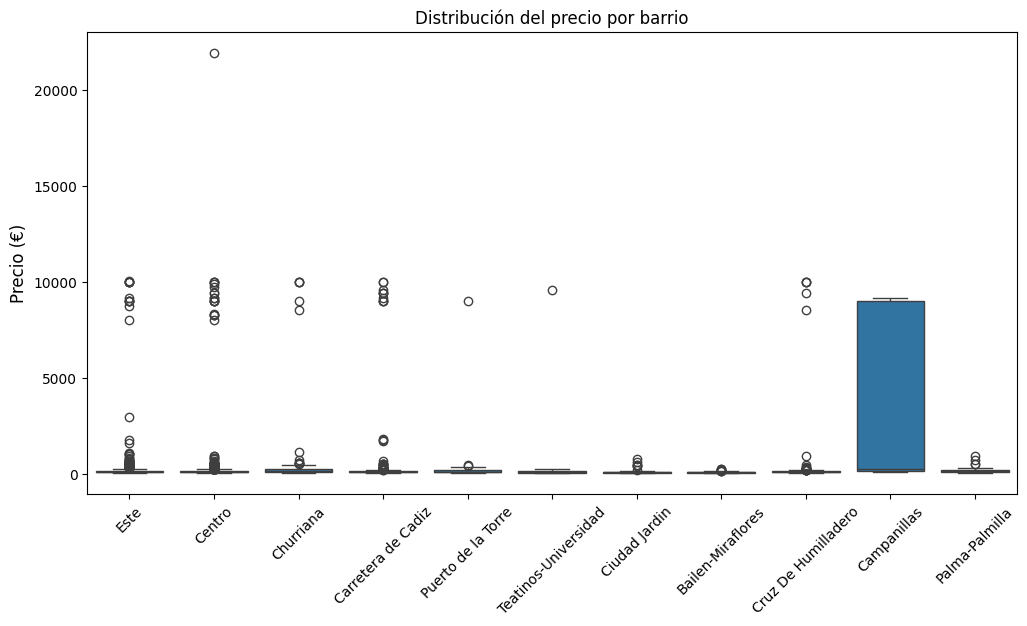

In [35]:
# Boxplot de la distribución del precio por barrio

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="neighbourhood", y="price")
plt.xticks(rotation=45)
plt.title("Distribución del precio por barrio")
plt.xlabel("")
plt.ylabel("Precio (€)", fontsize = 12)
plt.show()

In [36]:
df.groupby("neighbourhood")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood,,,,,,,,
Bailen-Miraflores,217.0,73.589862,34.870030,18.0,52.0,72.0,89.00,249.0
Campanillas,19.0,2989.210526,4213.307682,56.0,157.5,259.0,9000.00,9143.0
Carretera de Cadiz,666.0,251.097598,1138.625287,23.0,70.0,93.0,124.75,9999.0
Centro,4615.0,157.234670,650.193770,20.0,78.0,101.0,138.00,21911.0
Churriana,110.0,594.290909,1963.638447,27.0,75.0,111.5,231.75,9999.0
Ciudad Jardin,52.0,113.134615,151.273292,22.0,48.0,63.0,83.50,735.0
Cruz De Humilladero,294.0,255.663265,1233.656016,19.0,60.0,84.0,108.00,10000.0
Este,689.0,310.222061,1218.329532,22.0,79.0,101.0,150.00,10014.0
Palma-Palmilla,123.0,141.650407,116.655650,25.0,80.5,127.0,169.00,926.0


Descartamos la media como medida representativa, ya que la desviación típica es elevada en todos los barrios, lo que indica una fuerte 
dispersión y presencia de valores extremos. Por ello, utilizamos la mediana como estadístico central más robusto y ordenamos los barrios
de forma descendente según su mediana de precios.

In [37]:
mediana_precios = df.groupby("neighbourhood")["price"].median().sort_values(ascending=False)
print(mediana_precios)

neighbourhood
Campanillas             259.0
Palma-Palmilla          127.0
Churriana               111.5
Este                    101.0
Centro                  101.0
Puerto de la Torre       99.0
Carretera de Cadiz       93.0
Cruz De Humilladero      84.0
Bailen-Miraflores        72.0
Ciudad Jardin            63.0
Teatinos-Universidad     63.0
Name: price, dtype: float64


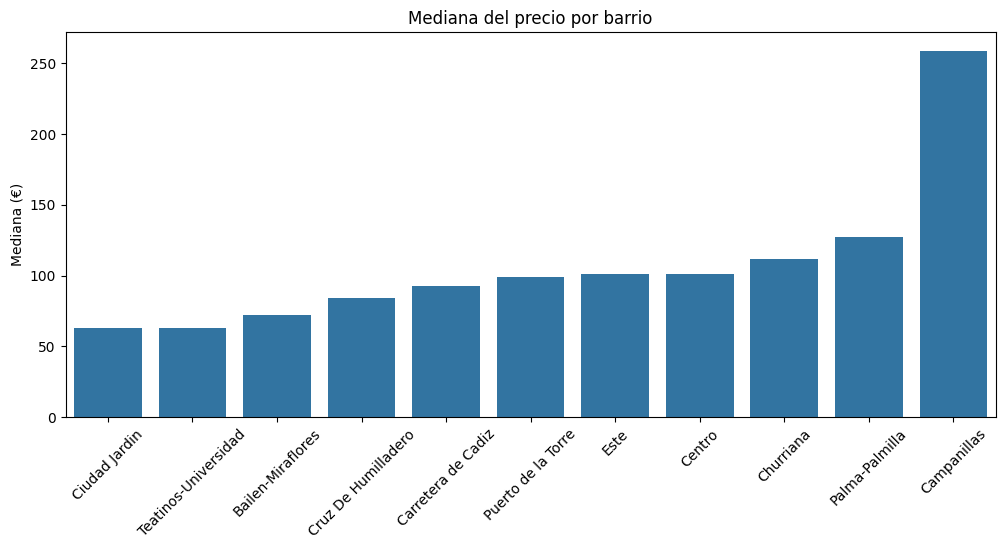

In [38]:
# Representamos la mediana del precio por barrio mediante un gráfico de barras

medianas = df.groupby("neighbourhood")["price"].median().sort_values()

plt.figure(figsize=(12,5))
sns.barplot(x=medianas.index, y=medianas.values)
plt.xticks(rotation=45)
plt.title("Mediana del precio por barrio")
plt.xlabel("")
plt.ylabel("Mediana (€)")
plt.show()

Se utiliza la mediana del precio por barrio como medida principal de tendencia central, ya que es menos sensible a valores extremos y ofrece una visión más fiel del comportamiento típico sin requerir la eliminación de outliers.  

Al comparar la media y la mediana por barrio, observamos que la media presenta valores anormalmente altos en algunas zonas. Esto se debe a la presencia de alojamientos con precios muy elevados (muy por encima del mercado) que inflan el valor de la media. Estos valores extremos suelen corresponder a viviendas de lujo o propiedades ubicadas en zonas residenciales exclusivas.  

La mediana, en cambio, permite describir el precio típico de cada barrio sin que estos casos excepcionales distorsionen el análisis, proporcionando una representación más robusta y realista del comportamiento general del mercado.

### 1. Análisis outliers

In [39]:
# Detectar outliers usando el percentil 99
umbral_99 = df["price"].quantile(0.99)
outliers = df[df["price"] > umbral_99]

In [40]:
outliers["room_type"].value_counts()

room_type
Entire home/apt    69
Name: count, dtype: int64

In [41]:
outliers["accommodates"].mode()

0    4
Name: accommodates, dtype: int64

In [42]:
outliers["Segmento Reseñas"].mode()

0    Pocas
Name: Segmento Reseñas, dtype: str

In [43]:
outliers["disponibilidad_clasificacion"].mode()

0    Alta
Name: disponibilidad_clasificacion, dtype: str

In [44]:
outliers["estancia_clasificacion"].mode()

0    Corta
Name: estancia_clasificacion, dtype: str

In [45]:
outliers["license"].isnull().sum()

np.int64(0)

Al analizar únicamente los outliers del conjunto de datos, observamos que todos ellos corresponden a apartamentos completos (*Entire home/apt*), lo que indica que los precios extremadamente altos están asociados a viviendas completas y no a habitaciones privadas o compartidas. La moda del número de huéspedes admitidos entre estos alojamientos es de 4, por lo que la mayoría de estas propiedades están orientadas a grupos pequeños o familias.  

En cuanto al volumen de reseñas, la mayoría de estos alojamientos se encuentran en el segmento de “Pocas reseñas”. Esto sugiere que, aunque son alojamientos activos, muchos de ellos no acumulan un historial extenso de estancias, posiblemente por tratarse de propiedades de gama alta o con precios elevados que limitan su rotación.  

Además, todos los outliers identificados cuentan con licencia y presentan una disponibilidad anual alta, para alojamientos de corta duración. 


### 2. Análisis de la mediana por persona y localización

In [46]:
# Analizamos el precio por persona / barrio, para ello creamos una nueva columna en el dataframe
df["precio_por_persona"] = df["price"] / df["accommodates"]
df.groupby(["neighbourhood"])["precio_por_persona"].median().sort_values(ascending=False)

neighbourhood
Campanillas             50.500000
Palma-Palmilla          33.500000
Centro                  30.000000
Churriana               29.425000
Este                    29.250000
Ciudad Jardin           25.583333
Puerto de la Torre      25.500000
Carretera de Cadiz      25.166667
Cruz De Humilladero     24.633333
Bailen-Miraflores       21.250000
Teatinos-Universidad    20.000000
Name: precio_por_persona, dtype: float64

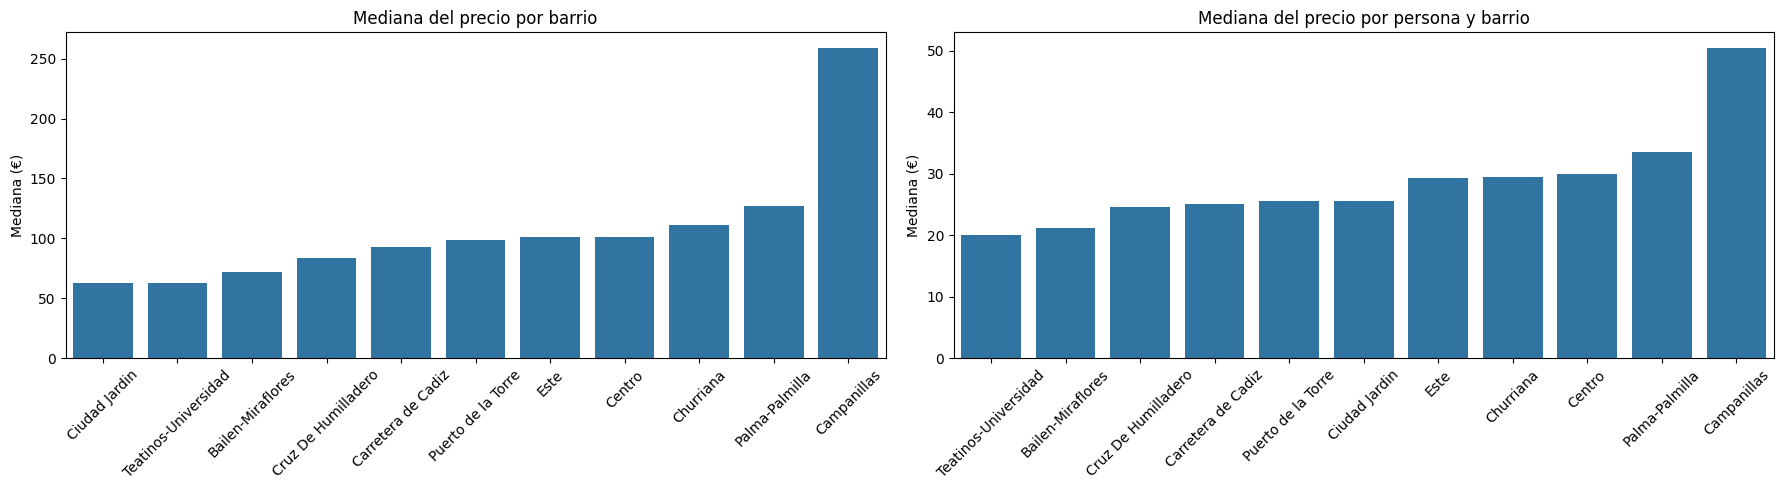

In [47]:
# Comparación de la mediana en precio por barrio y precio por persona y barrio

medianas_por_persona = df.groupby(["neighbourhood"])["precio_por_persona"].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18,5))

# --- Gráfico 1: Mediana del precio por barrio ---
sns.barplot(
    ax=axes[0],
    x=medianas.index,
    y=medianas.values
)
axes[0].set_title("Mediana del precio por barrio")
axes[0].set_ylabel("Mediana (€)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# --- Gráfico 2: Mediana del precio por persona y barrio ---
sns.barplot(
    ax=axes[1],
    x=medianas_por_persona.index,
    y=medianas_por_persona.values
)
axes[1].set_title("Mediana del precio por persona y barrio")
axes[1].set_ylabel("Mediana (€)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

La comparación entre la mediana del precio total y la mediana del precio por persona revela diferencias importantes entre barrios. Campanillas destaca como la zona más cara tanto en términos absolutos como por persona, lo que indica un mercado claramente premium. En contraste, barrios como Centro o Churriana presentan precios totales elevados, pero su precio por persona es más moderado debido a una mayor capacidad de los alojamientos.  

Por otro lado, zonas como Palma-Palmilla muestran precios totales relativamente bajos, pero un precio por persona más elevado, lo que sugiere alojamientos de menor tamaño. Teatinos-Universidad se posiciona como el barrio más económico en ambos indicadores, coherente con su perfil orientado a estudiantes.  

En conjunto, el análisis demuestra que el precio total no siempre refleja el coste real para el huésped, y que el precio por persona aporta una visión más ajustada de la accesibilidad económica de cada barrio.

### 3. Matriz correlaciones y heat map entre variables numéricas

In [48]:
correlaciones = df[["price", "accommodates", "number_of_reviews", "review_scores_rating", "availability_365"]].corr()
correlaciones

,price,accommodates,number_of_reviews,review_scores_rating,availability_365
price,1.000000,0.108125,-0.060614,-0.003427,0.087781
accommodates,0.108125,1.000000,-0.077790,0.063968,0.046937
number_of_reviews,-0.060614,-0.077790,1.000000,0.143385,-0.101831
review_scores_rating,-0.003427,0.063968,0.143385,1.000000,-0.069825
availability_365,0.087781,0.046937,-0.101831,-0.069825,1.000000


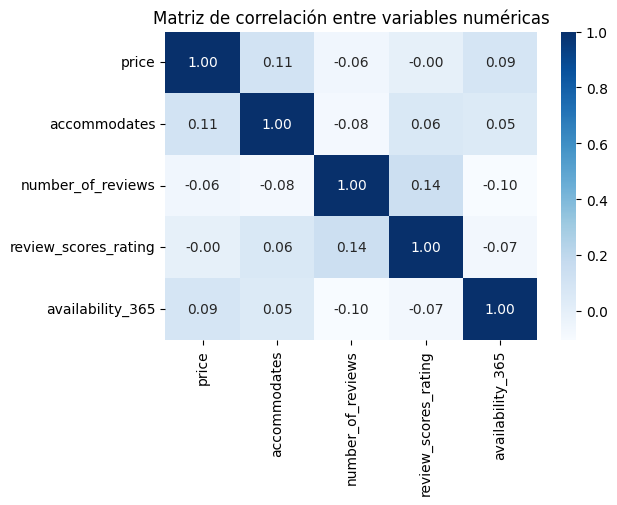

In [49]:
# Generamos un mapa de calor para verlo de forma mas visual
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

La matriz de correlación muestra que no existen relaciones lineales fuertes entre las variables numéricas analizadas. El precio presenta correlaciones muy bajas con la capacidad, el número de reseñas, la puntuación y la disponibilidad, lo que indica que estos factores no explican de forma directa las variaciones de precio. La única relación ligeramente destacable es la correlación positiva entre número de reseñas y rating, aunque sigue siendo débil.  

También se observa una correlación negativa entre reseñas y disponibilidad, coherente con el hecho de que los alojamientos más reservados acumulan más reseñas y tienen menos días libres.  

En conjunto, las correlaciones sugieren que el precio y la actividad de los alojamientos dependen de factores no numéricos o no incluidos en este conjunto de variables.


### 4. Distribución del precio por tipo de habitación

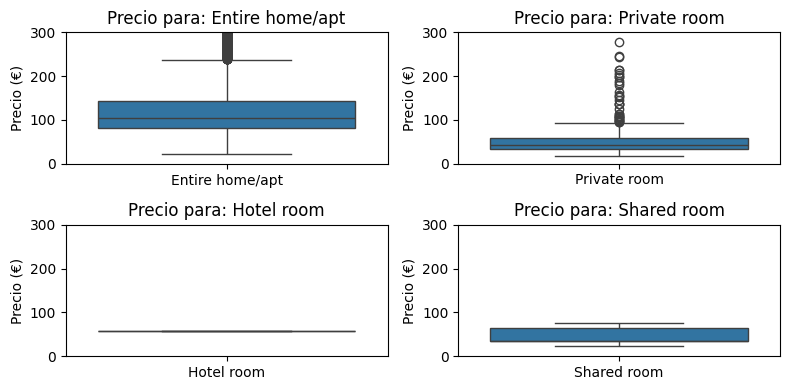

In [50]:
# Distribución del precio por tipo de habitación
 
tipos = df["room_type"].unique()

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, tipo in enumerate(tipos):
    sns.boxplot(
        data=df[df["room_type"] == tipo],
        x="room_type",
        y="price",
        ax=axes[i]
    )
    axes[i].set_title(f"Precio para: {tipo}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Precio (€)")
    axes[i].set_ylim(0, 300)  # ajustamos el límite del eje y para ver los valores mas bajos

plt.tight_layout()
plt.show()


Los diagramas de caja muestran diferencias claras entre los tipos de alojamiento. Los apartamentos completos (Entire home/apt) presentan los precios más altos y también la mayor variabilidad, con numerosos valores extremos que indican la presencia de alojamientos significativamente más caros. Las habitaciones privadas (Private room) tienen precios mucho más bajos y una distribución más concentrada, aunque también aparecen algunos outliers. Las habitaciones compartidas (Shared room) son las más económicas y muestran una variabilidad reducida. Por su parte, las habitaciones de hotel (Hotel room) presentan precios intermedios y una distribución relativamente estable. 
 
En conjunto, los resultados confirman que los alojamientos completos son claramente más caros, mientras que las habitaciones privadas y compartidas ofrecen opciones más económicas y homogéneas.

### 5. Relación entre capacidad y precio (mediana)

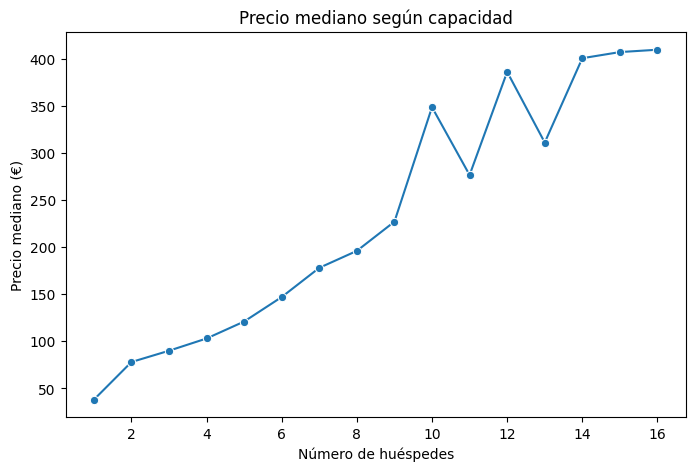

In [51]:
# Relación entre capacidad y precio (mediana)

medianas = df.groupby("accommodates")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=medianas,
    x="accommodates",
    y="price",
    marker="o"
)
plt.title("Precio mediano según capacidad")
plt.xlabel("Número de huéspedes")
plt.ylabel("Precio mediano (€)")
plt.show()


El gráfico de la mediana del precio según la capacidad muestra una tendencia ascendente clara: a medida que aumenta el número de huéspedes que pueden alojarse en un apartamento , también lo hace el precio mediano. Aunque existen pequeñas fluctuaciones en capacidades altas, la tendencia general confirma que los alojamientos más grandes tienden a ser más caros.

### 6. Análisis multivariante entre la mediana (€) y el tipo de habitación

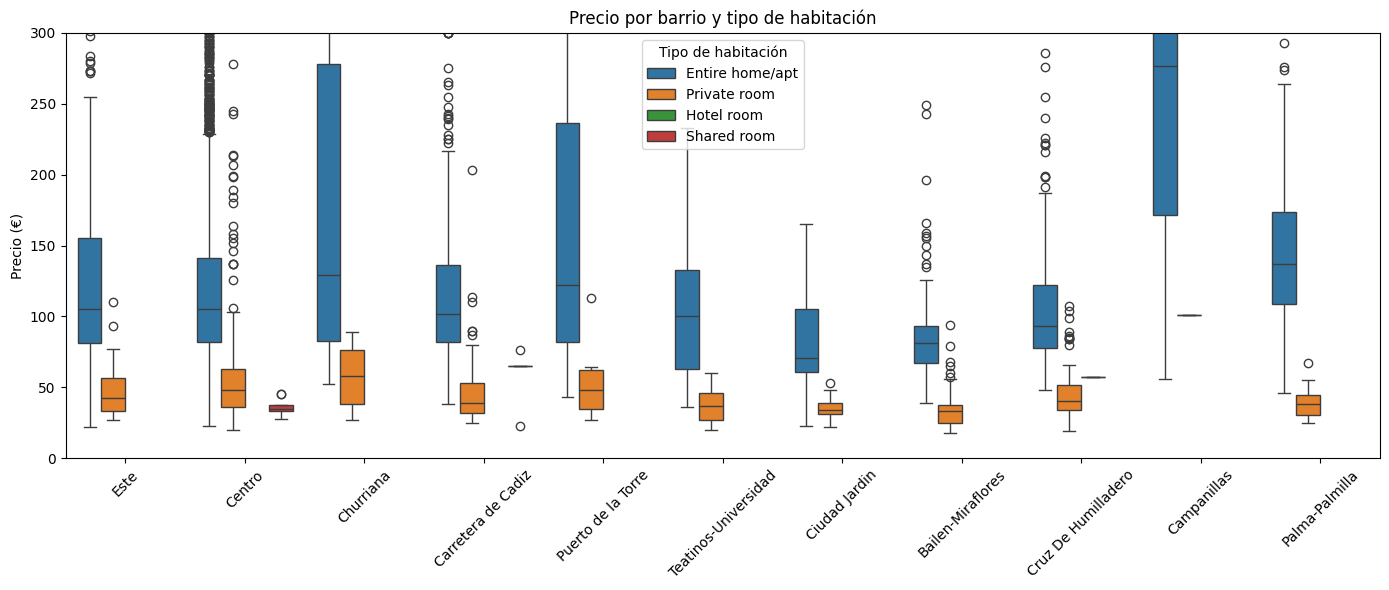

In [52]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x="neighbourhood",
    y="price",
    hue="room_type"
)
plt.xticks(rotation=45)
plt.title("Precio por barrio y tipo de habitación")
plt.ylabel("Precio (€)")
plt.xlabel("")
plt.legend(title="Tipo de habitación")
plt.ylim(0, 300)  # para evitar que los outliers aplasten el gráfico
plt.tight_layout()
plt.show()


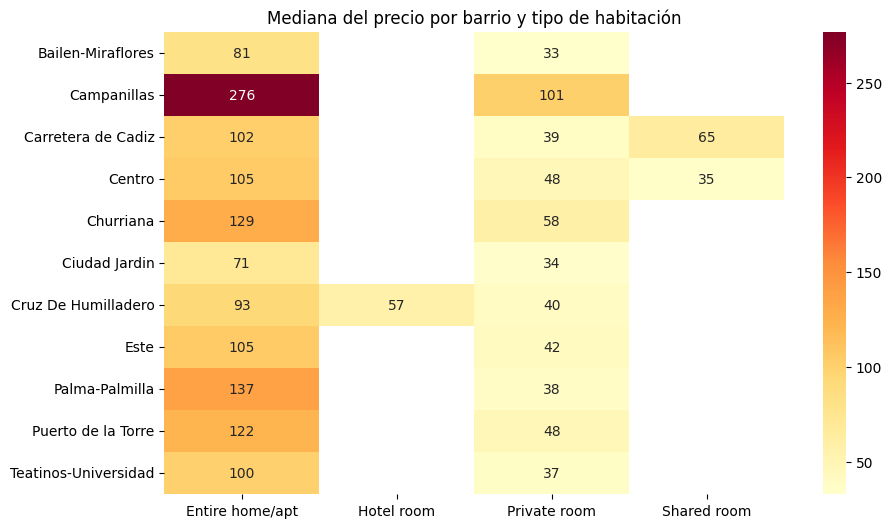

In [53]:
tabla = df.pivot_table(
    values="price",
    index="neighbourhood",
    columns="room_type",
    aggfunc="median"
)

plt.figure(figsize=(10,6))
sns.heatmap(tabla, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Mediana del precio por barrio y tipo de habitación")
plt.xlabel("")
plt.ylabel("")
plt.show()

La comparación entre el boxplot por barrio y tipo de habitación y el heatmap de medianas permite reforzar las conclusiones del análisis multivariante. Mientras que el boxplot muestra la dispersión y variabilidad interna de los precios en cada combinación de barrio y tipo de alojamiento, el heatmap sintetiza esa información destacando las tendencias centrales de forma clara y comparativa. Juntos, ambos gráficos revelan que las viviendas completas son sistemáticamente más caras en todos los barrios, aunque con variaciones notables según la zona, y que las habitaciones privadas y compartidas mantienen precios más homogéneos. Esta combinación de visualizaciones confirma que la localización y el tipo de habitación interactúan de manera decisiva en la determinación del precio, ofreciendo una visión más completa que cualquiera de los gráficos por separado.

### 7. Análisis precio (mediana) y número de reseñas

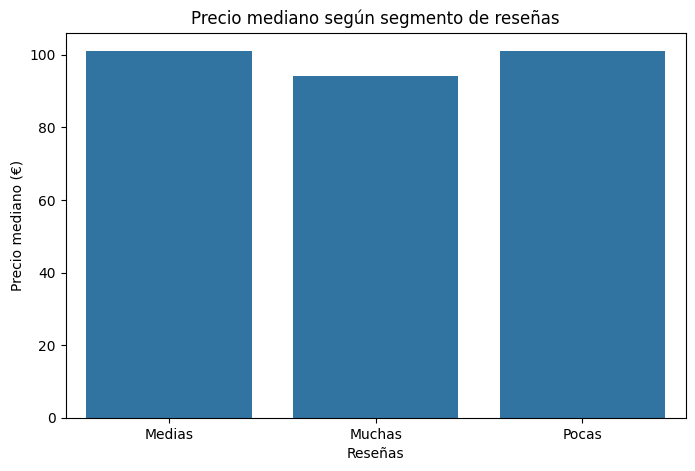

In [54]:
medianas_seg = df.groupby("Segmento Reseñas")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_seg, x="Segmento Reseñas", y="price")
plt.title("Precio mediano según segmento de reseñas")
plt.xlabel("Reseñas")
plt.ylabel("Precio mediano (€)")
plt.show()


In [55]:
df["number_of_reviews"].corr(df["price"])

np.float64(-0.06061398372488425)

El análisis del precio por segmento de reseñas muestra que no existe una relación clara entre ambas variables. Los alojamientos con muchas reseñas presentan precios medianos ligeramente inferiores, pero las diferencias entre segmentos son pequeñas y no siguen un patrón consistente.

### 8. Análisis precio (mediana) y disponibilidad anual

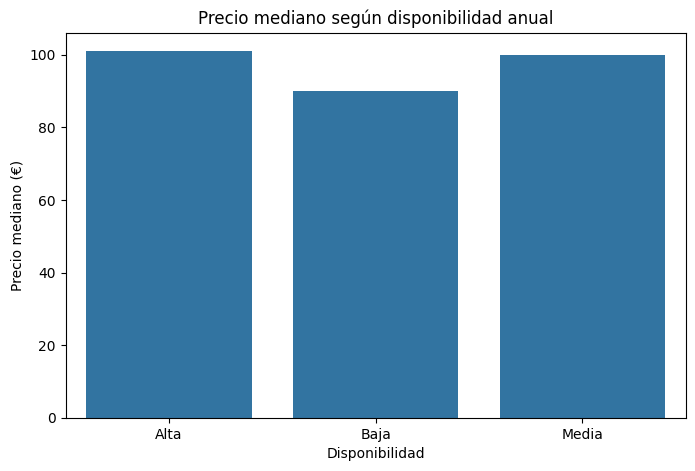

In [56]:
medianas_disp = df.groupby("disponibilidad_clasificacion")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_disp, x="disponibilidad_clasificacion", y="price")
plt.title("Precio mediano según disponibilidad anual")
plt.xlabel("Disponibilidad")
plt.ylabel("Precio mediano (€)")
plt.show()


In [57]:
df["availability_365"].corr(df["price"])

np.float64(0.08778137068158547)

La correlación entre disponibilidad anual y precio es de 0.08, un valor extremadamente bajo que indica ausencia de relación lineal entre ambas variables. Esto confirma que la disponibilidad no depende del precio, y que la demanda está influida por otros factores como la ubicación, el tipo de alojamiento o la capacidad del alojamiento.

### 9. Analisis de la duración mínima del alojamiento (estancia)

In [58]:
moda_estancia_barrio = df.groupby("neighbourhood")["estancia_clasificacion"].agg(lambda x: x.mode().iloc[0])
moda_estancia_barrio

neighbourhood
Bailen-Miraflores       Corta
Campanillas             Corta
Carretera de Cadiz      Corta
Centro                  Corta
Churriana               Corta
Ciudad Jardin           Corta
Cruz De Humilladero     Corta
Este                    Corta
Palma-Palmilla          Corta
Puerto de la Torre      Corta
Teatinos-Universidad    Corta
Name: estancia_clasificacion, dtype: str

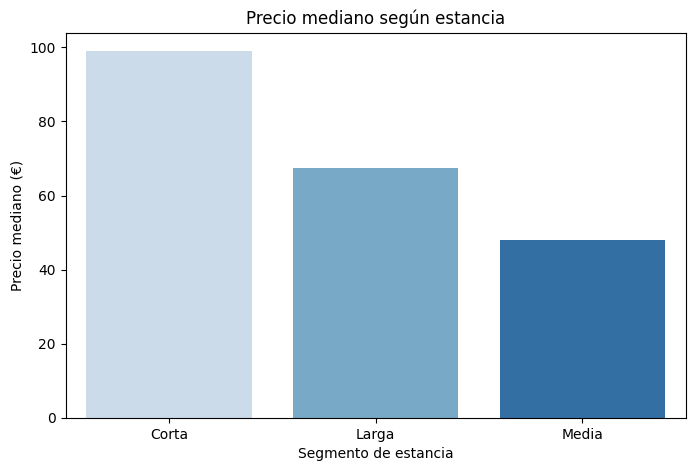

In [59]:
medianas_estancia = df.groupby("estancia_clasificacion")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_estancia, x="estancia_clasificacion", y="price", palette="Blues")
plt.title("Precio mediano según estancia")
plt.xlabel("Segmento de estancia")
plt.ylabel("Precio mediano (€)")
plt.show();

El análisis del precio mediano por segmento de estancia muestra diferencias claras entre los tipos de alojamiento. Las estancias cortas son las más caras, seguidas por las estancias largas, mientras que las estancias de duración media presentan los precios más bajos. Este patrón es coherente con el comportamiento habitual del mercado turístico: las estancias cortas suelen tener un precio por noche más elevado debido a la alta rotación y a los costes fijos asociados, mientras que las estancias largas tienden a beneficiarse de descuentos progresivos. Por su parte, las estancias medias se sitúan en un punto intermedio, donde la tarifa por noche suele ser más competitiva para atraer a viajeros que buscan una estancia prolongada pero no mensual.

### 10. Análisis del precio por barrio según tipo de host

In [61]:
moda_host_barrio = (
    df.groupby("neighbourhood")["host_type"]
      .agg(lambda x: x.mode()[0])
      .reset_index()
)

moda_host_barrio


,neighbourhood,host_type
0,Bailen-Miraflores,Particular
1,Campanillas,Particular
2,Carretera de Cadiz,Semi-profesional
3,Centro,Empresa/Hotel
4,Churriana,Particular
5,Ciudad Jardin,Particular
6,Cruz De Humilladero,Semi-profesional
7,Este,Semi-profesional
8,Palma-Palmilla,Empresa/Hotel
9,Puerto de la Torre,Particular


# Conclusión final: por qué el Centro no es la zona más cara

Aunque el Centro es el barrio con mayor demanda turística y el que concentra la mayor cantidad de alojamientos, los datos muestran que **su mediana de precios no es la más alta**. Esto se debe a varios factores estructurales del mercado que afectan directamente a esta métrica.


### **1. El Centro tiene una oferta enorme y muy homogénea**  
Con más de 4.000 alojamientos, el Centro presenta una distribución amplia pero relativamente estable, donde predominan estudios y alojamientos compactos.  
Esta abundancia de opciones hace que la **mediana se mantenga contenida**, ya que la mayoría de precios se agrupan en rangos similares.

**Mucha oferta + precios similares → mediana estable y moderada.**

---

### **2. Alta profesionalización del host en el Centro**  
En este barrio predominan **hosts profesionales y empresas**, que aplican estrategias de pricing más estables para competir en un mercado saturado.  
Esto reduce la dispersión y evita que la mediana suba.

**Profesionalización → precios más consistentes → mediana más baja.**

---

### **3. Los barrios más caros tienen menos oferta y alojamientos más grandes**  
Barrios como Campanillas, Churriana, Este o Puerto de la Torre tienen:  
- menos alojamientos,  
- viviendas más amplias,  
- mayor presencia de casas completas, chalets y villas.  

**Poca oferta + alojamientos grandes → mediana más alta.**

En los barrios con menor oferta, además predominan los **hosts particulares**, que no necesitan moderar precios.  
Esto genera una distribución más dispersa y empuja la mediana hacia arriba.

**Menos competencia → precios más altos → mediana elevada.**

---

### **4. Los outliers de lujo afectan más a barrios pequeños**  
Aunque la mediana es robusta, en barrios con pocos alojamientos, la presencia de **villas, chalets y casas de lujo** puede desplazarla hacia arriba porque representan una proporción significativa del total.

---

**El Centro no es el barrio más caro porque su enorme oferta, la profesionalización de los hosts y la homogeneidad de los alojamientos mantienen la mediana de precios en niveles moderados. En cambio, los barrios con menos oferta, más alojamientos grandes y predominio de hosts particulares presentan medianas más altas. Los datos refutan la hipótesis inicial y sitúan al Centro en una posición intermedia dentro del mercado.**


## **HIPÓTESIS 2**

#### ***El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas.***

**JUSTIFICACIÓN DE LA HIPÓTESIS**

La lógica detrás de esto suele ser que los "anfitriones novatos" o con propiedades nuevas tienden a sobrevalorar su piso o no tienen el precio optimizado, mientras que los que tienen muchas reseñas (veteranos) ajustan precios para mantener la ocupación.

**ANÁLISIS DE LA VARIABLE PRICE (PRECIO)**

El objetivo es analizar cómo se coporta el dinero en el dataset. Buscamos entender la dispersión.

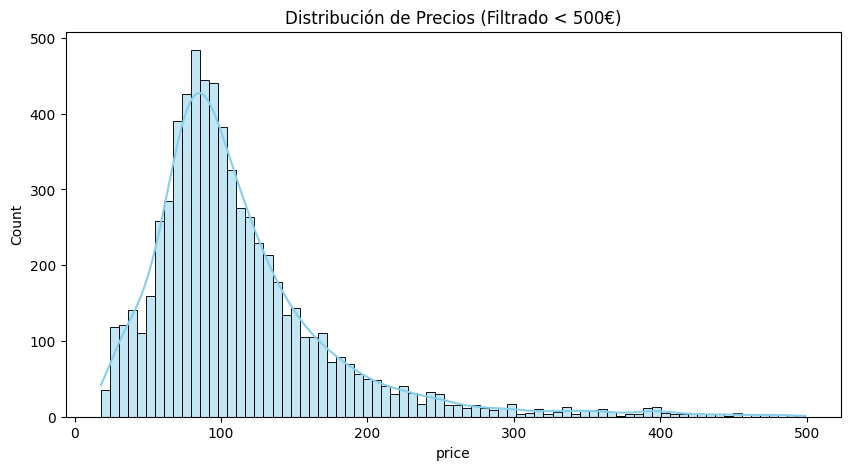

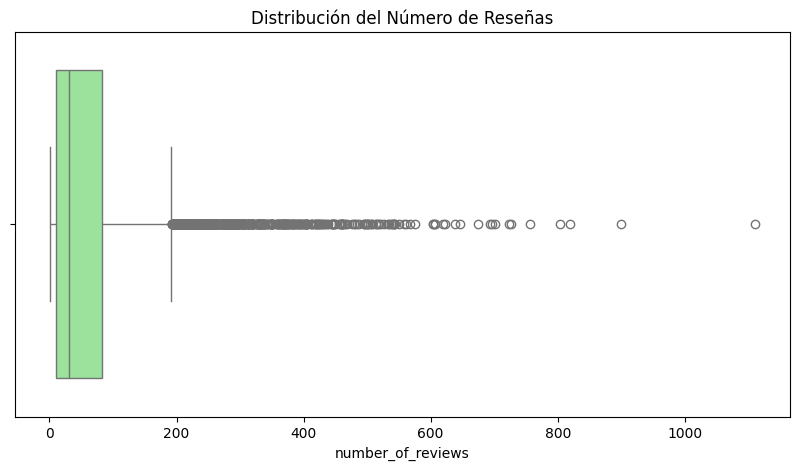

              price  number_of_reviews
count   6861.000000        6861.000000
mean     199.602973          65.558956
std      885.409832          92.460037
min       18.000000           1.000000
25%       75.000000          10.000000
50%       99.000000          30.000000
75%      137.000000          83.000000
max    21911.000000        1110.000000


In [35]:
# 1. Histograma de precios (limitamos a 500 para ver mejor el grueso de los datos)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 500]['price'], kde=True, color='skyblue')
plt.title('Distribución de Precios (Filtrado < 500€)')
plt.show()

# 2. Boxplot de reseñas
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['number_of_reviews'], color='lightgreen')
plt.title('Distribución del Número de Reseñas')
plt.show()

# 3. Resumen estadístico
print(df[['price', 'number_of_reviews']].describe())

**ANÁLISIS UNIVARIANTE: PRECIO**

- **El precio típico:** El valore central (mediana) es de 99€. Es preferible usar este dato antes que la media (199€), ya que la media está "inflada" por unos pocos alojamientos de lujo.
- **Presencia de Outliers:** Existe un valor máximo de 21,911€. Esto indica que existen propiedades excepcionales o errores de carga que podrían sesgar los promedios en análisis posteriores.
- **Rango común:** El 75% de los alojamientos cuesta menos de 137€, lo que sitúa a la gran mayoría en un rango de precio moderado.

**ANÁLISIS UNIVARIANTE: RESEÑAS**  

- **Volumen de actividad:** El alojamiento promedio tiene unas 30 reseñas (mediana).
- **Definición de "Pocas reseñas":** El primer cuartil (25%) nos indica que una parte significativa de los alojamientos tiene 10 reseñas o menos. Este será nuestro grupo de control para la hipótesis.
- **Concentración:** Existe un sesgo importante; hay muchísimos alojamientos con pocas reseñas y muy pocos "superventas" (el máximo es 1,100 reseñas).

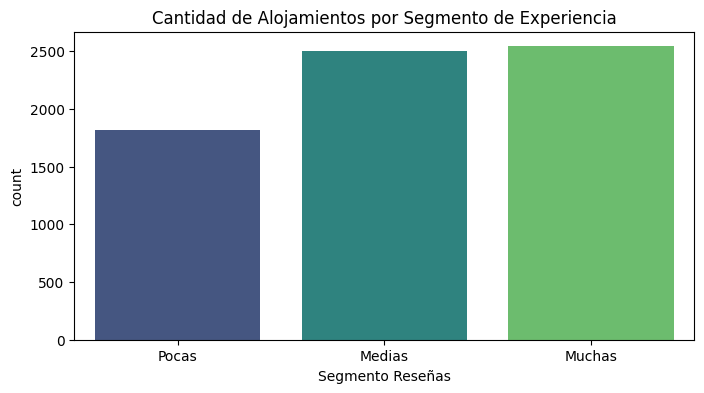

In [36]:
# Voy a agrupar por número de reseñas en grupos para el análisis posterior(1) 
cortes = [0, 10, 50, df['number_of_reviews'].max()]
etiquetas = ['Pocas', 'Medias', 'Muchas']
df['Segmento Reseñas'] = pd.cut(df['number_of_reviews'], bins=cortes, labels=etiquetas, include_lowest=True)

# Gráfico de barras para ver cuántos hay en cada grupo
plt.figure(figsize=(8, 4))
sns.countplot(x='Segmento Reseñas', data=df, palette='viridis')
plt.title('Cantidad de Alojamientos por Segmento de Experiencia')
plt.show()

Tenemos una muestra sana. Tenemos casi la misma cantidad de alojamientos en "Medias" y "Muchas", y un grupo sólido de "Pocas". Esto hace que cualquier conclusión que saquemos sea estadísticamente fiable.

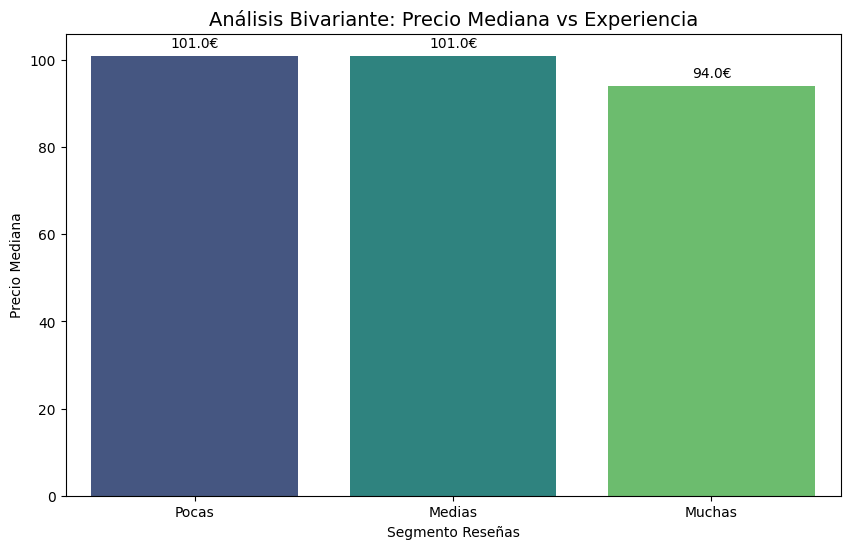

In [37]:
# 2. Crear la tabla resumen asegurando que 'Segmento Reseñas' sea una COLUMNA (con reset_index)
tabla_grafico = df.groupby('Segmento Reseñas', observed=False)['price'].median().reset_index()
tabla_grafico.columns = ['Segmento Reseñas', 'Precio Mediana']

# 3. Dibujar el gráfico usando esa tabla
plt.figure(figsize=(10, 6))
plot = sns.barplot(
    data=tabla_grafico, 
    x='Segmento Reseñas', 
    y='Precio Mediana', 
    palette='viridis'
)

# 4. Añadir etiquetas de datos encima de las barras
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f') + '€', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Análisis Bivariante: Precio Mediana vs Experiencia', fontsize=14)
plt.show()

In [163]:
# Separo en mis tres grupos según sus etiquetas y utilizo solo los números de la columna de precio
df.groupby('Segmento Reseñas', observed=False)['price'].describe()

,count,mean,std,min,25%,50%,75%,max
Segmento Reseñas,,,,,,,,
Pocas,1816.0,348.122247,1419.910112,18.0,75.0,101.0,144.0,10014.0
Medias,2503.0,169.294447,664.352939,22.0,77.0,101.0,141.0,10000.0
Muchas,2542.0,123.344611,468.262422,19.0,72.0,94.0,128.0,21911.0


**ANÁLISIS BIVARIANTE**  

Comparando una variable categórica (los tres grupos de reseñas) con una numérica (las medianas del precio).
- **Diferencia de precios:** Destacamos que el grupo de "Pocas reseñas" tiene una mediana de 101€, mientras que el grupo de "Muchas" baja a 94€.
- **Impacto en los Promedios:** La diferencia es aún más notable en la media (348€ vs. 123€), lo que indica que los alojameintos más caros y exclusivos suelen tener pocas reseñas.

Aunque se confirma la relación, la debilidad de la correlación sugiere que el precio está influenciado por otras variables de mayor peso, como el tipo de alojamiento o la ubicación. Como siguiente paso, se realiza un análisis multivariante para observar si los alojamientos con pocas reseñas son mayoritariamente 'Casas completas' frente a 'Habitaciones privadas'.


**ANÁLISIS MULTIVARIANTE**  
*¿La diferencia de precio se debe realmente a las reseñas o hay algo más escondido?*  

El último paso sería ver si ese precio de 101€ de los de "Pocas" se debe a que son casi todos "Casas completas". Vamos a sacar una tabla que cruce **Categoría de Reseñas + Room Type + Precio**.

In [38]:
# Cruzamos las categorías de reseñas con el tipo de habitación
tabla_multi = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().unstack()
print(tabla_multi)

room_type         Entire home/apt  Hotel room  Private room  Shared room
Segmento Reseñas                                                        
Pocas                       107.0         NaN          49.0         34.5
Medias                      106.0         NaN          42.0         45.0
Muchas                      100.0        57.0          40.0         50.0


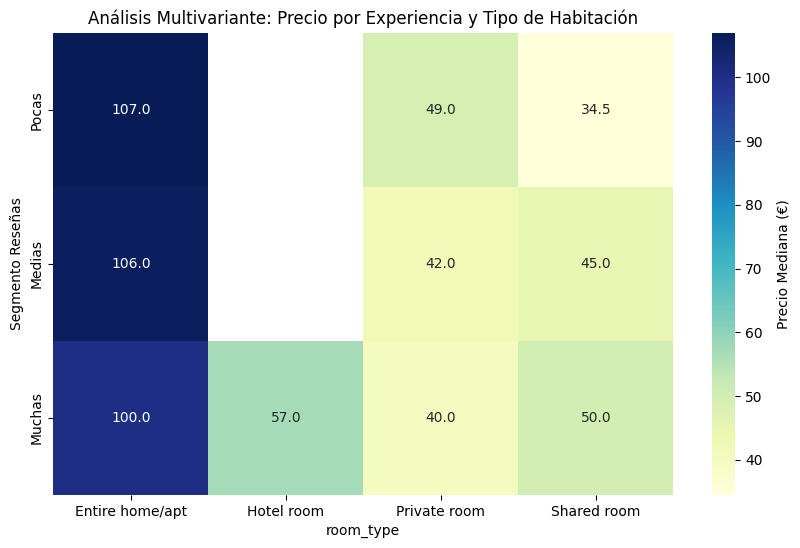

In [165]:
# Analizamos la mediana de precio cruzando Experiencia y Tipo de alojamiento
df_multi = df.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().unstack()

# Lo visualizamos con un mapa de calor (Heatmap) para que se entienda al momento
plt.figure(figsize=(10, 6))
sns.heatmap(df_multi, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Precio Mediana (€)'})
plt.title('Análisis Multivariante: Precio por Experiencia y Tipo de Habitación')
plt.show()

El análisis multivariante revela que la hipótesis se confirma de forma sólida en los segmentos principales del mercado (Apartamentos completos y Habitaciones privadas), donde el precio mediano desciende conforme aumenta el número de reseñas.

Sin embargo, se ha detectado una excepción significativa en las Habitaciones compartidas, donde la tendencia se invierte: los alojamientos con más reseñas son más caros (50€) que los nuevos (34.5€). Esto sugiere que en el segmento 'low-cost', la confianza generada por las reseñas es un activo que permite subir el precio, a diferencia del resto del mercado donde los nuevos anuncios parecen entrar con precios de prueba superiores a la media.

### **Conclusión de la Hipótesis 2: confirmada con excepciones**

La hipótesis es válida para el grueso del mercado (casas y cuartos privados), pero no para los compartidos. Además, es posible que los alojamientos con pocas reseñas presenten precios más altos porque están disponibles en fechas de alta demanda (cuando los baratos ya se han reservado), lo que hace que su "precio medio" parezca más alto.

## **HIPÓTESIS 3**

#### ***La demanda de alojamientos en Málaga (medida por el volumen de reseñas mensuales) presenta un pico de crecimiento superior al 50% durante el tercer trimestre del año (julio, agosto, septiembre), siendo el Distrito Centro el que mantiene una demanda más estable durante el resto del año frente a las otras zonas.***

**PREPARACIÓN Y UNIÓN DE DATOS**

Para comprobar la veracidad de esta hipótesis, vamos a utilizar las reseñas como indicador indirecto de la ocupación. Para que el archivo de reseñas no sea un "archivo suelto", necesitamos inyectarle la localización. Al unirlo con los datos principales, cada reseña tendrá asignado un barrio (neighbourhood).

In [166]:
# Cargar los datasets específicos para el análisis estacional
df_original = pd.read_csv("../../src/data/listings.csv")
df_reviews = pd.read_csv("../../src/data/reviews.csv")

# Limpieza express y conversión de fechas para la unión
df_hip3 = df_original.drop(columns=["neighbourhood_group", "latitude", "longitude"])
df_hip3['last_review'] = pd.to_datetime(df_hip3['last_review'], format='%Y-%m-%d')
df_reviews['date'] = pd.to_datetime(df_reviews['date'], format='%Y-%m-%d')

df_hip3 = df_hip3.dropna(subset=["price"])

# Unión (Merge) por el ID del alojamiento
df_merged = pd.merge(df_reviews, df_hip3[['id', 'neighbourhood']], left_on='listing_id', right_on='id')
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 465148 entries, 0 to 465147
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   listing_id     465148 non-null  int64         
 1   date           465148 non-null  datetime64[us]
 2   id             465148 non-null  int64         
 3   neighbourhood  465148 non-null  str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 14.2 MB


In [167]:
df_merged = df_merged.drop(columns=['listing_id']) # Elimino la columna 'listing_id', ya que es idéntica a 'id'

**ANÁLISIS UNIVARIANTE (SERIE TEMPORAL)**  

Vamos a crear un gráfico de líneas donde el eje X sea el tiempo (meses y el eje Y sea el conteo de reseñas)

In [168]:
# Creamos una columna de 'Año-Mes' para agrupar fácilmente
df_merged['month_year'] = df_merged['date'].dt.to_period('M')

In [169]:
# Contamos cuántas reseñas hay por cada mes en todo Málaga

# Contamos reseñas por mes
resenas_por_mes = df_merged.groupby('month_year').size().reset_index(name='num_reviews')

# Convertimos month_year a timestamp para que quede bien en  Matplotlib
resenas_por_mes['month_year'] = resenas_por_mes['month_year'].dt.to_timestamp()

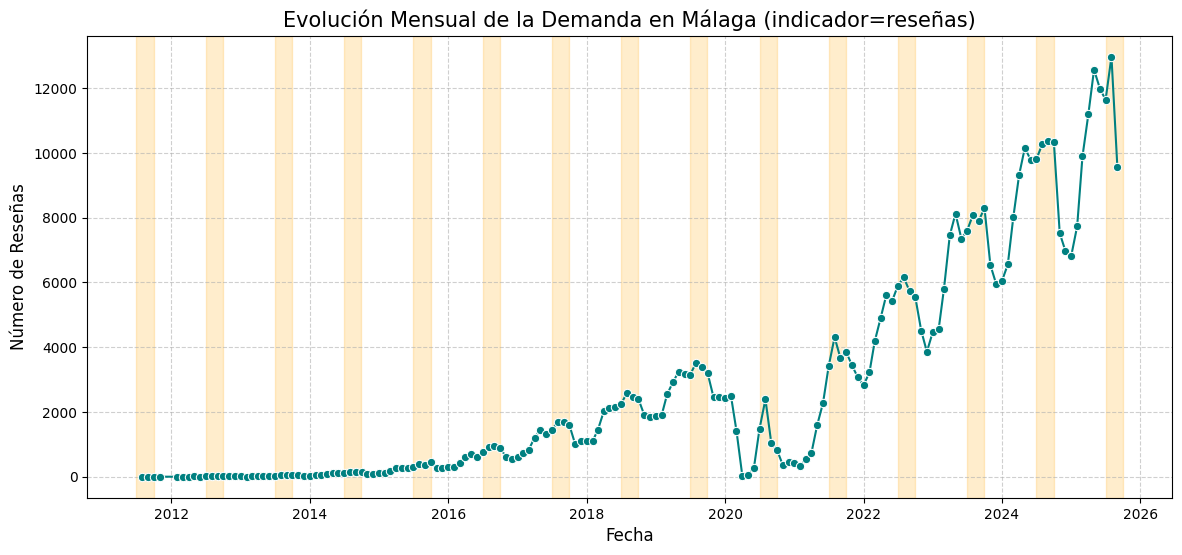

In [170]:
# Visualización de la serie temporal: Para ver si existen los famosos "picos" de julio, agosto y septiembre
plt.figure(figsize=(14, 6))
sns.lineplot(data=resenas_por_mes, x='month_year', y='num_reviews', marker='o', color='teal')

plt.title('Evolución Mensual de la Demanda en Málaga (indicador=reseñas)', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Reseñas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Añadimos líneas verticales para marcar los veranos (Q3)
for year in resenas_por_mes['month_year'].dt.year.unique():
    plt.axvspan(pd.Timestamp(f'{year}-07-01'), pd.Timestamp(f'{year}-09-30'), 
                color='orange', alpha=0.2, label='Verano (Q3)' if year == 2024 else "")

plt.show()

Al haber días con muchas reseñas y días con cero, la línea sube y baja violentamente. Además, el eje X está colapsado porque hay demasiada información histórica.

Para que el gráfico sea legible y útil para nuestro análisis de estacionalidad, necesitamos "suavizar" la curva agrupando por meses y filtrar el ruido.

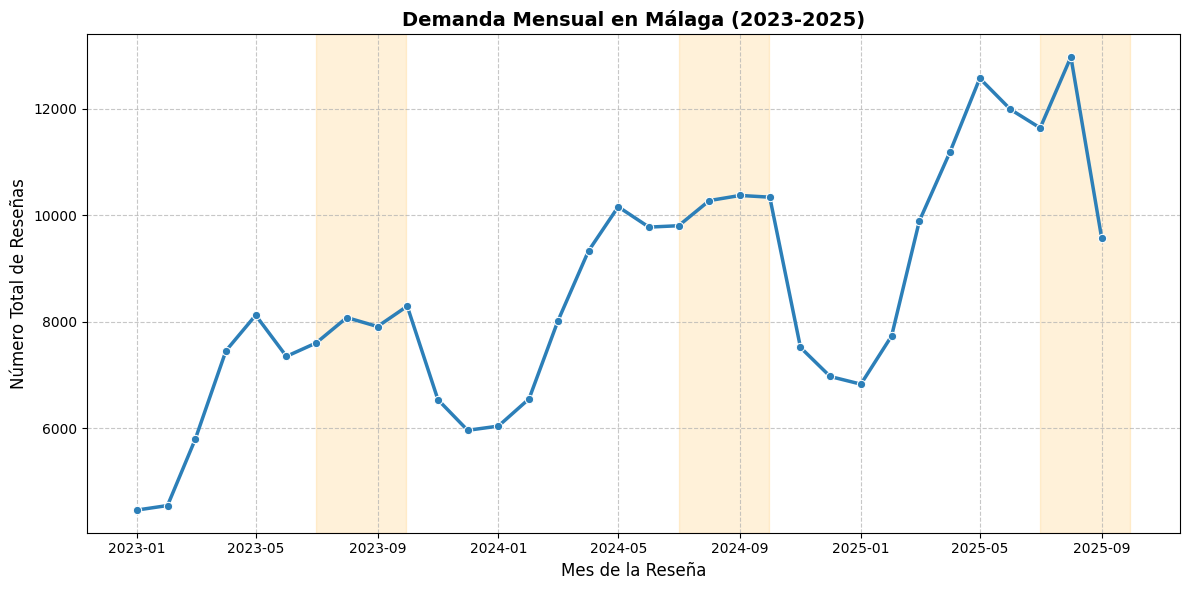

In [171]:
# La Solución: Agrupar y Filtrar
# Vamos a añadir el filtrado por años (2023-2025) para que el gráfico sea "limpio" y se pueda ver claramente si el verano sube un 50%.

# 1. FILTRAR: Nos quedamos solo con los últimos años para ver la realidad actual
df_reciente = df_merged[df_merged['date'].dt.year >= 2023].copy()

# 2. AGRUPAR por Mes: Para eliminar el "diente de sierra"
# Creamos una columna Mes-Año
df_reciente['month_year'] = df_reciente['date'].dt.to_period('M')
resenas_mensuales = df_reciente.groupby('month_year').size().reset_index(name='conteo')

# Convertir a timestamp para que el eje X se vea bien
resenas_mensuales['month_year'] = resenas_mensuales['month_year'].dt.to_timestamp()

# 4. Gráfico Limpio
plt.figure(figsize=(12, 6))
sns.lineplot(data=resenas_mensuales, x='month_year', y='conteo', marker='o', linewidth=2.5, color='#2c7fb8')

plt.title('Demanda Mensual en Málaga (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Mes de la Reseña', fontsize=12)
plt.ylabel('Número Total de Reseñas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar los veranos para la hipótesis
for year in [2023, 2024, 2025]:
    plt.axvspan(pd.Timestamp(f'{year}-07-01'), pd.Timestamp(f'{year}-09-30'), 
                color='orange', alpha=0.15)

plt.tight_layout()
plt.show()

In [172]:
# Vemos el nombre de la columna, nos interesa la de los distritos
df_merged.columns

Index(['date', 'id', 'neighbourhood', 'month_year'], dtype='str')

In [173]:
# Vemos cuántos distritos hay
conteo_distritos = df_merged['neighbourhood'].value_counts()
print(conteo_distritos)

neighbourhood
Centro                  342156
Carretera de Cadiz       41727
Este                     33426
Cruz De Humilladero      17267
Bailen-Miraflores        15360
Churriana                 5344
Palma-Palmilla            2781
Ciudad Jardin             2604
Teatinos-Universidad      1926
Puerto de la Torre        1686
Campanillas                871
Name: count, dtype: int64


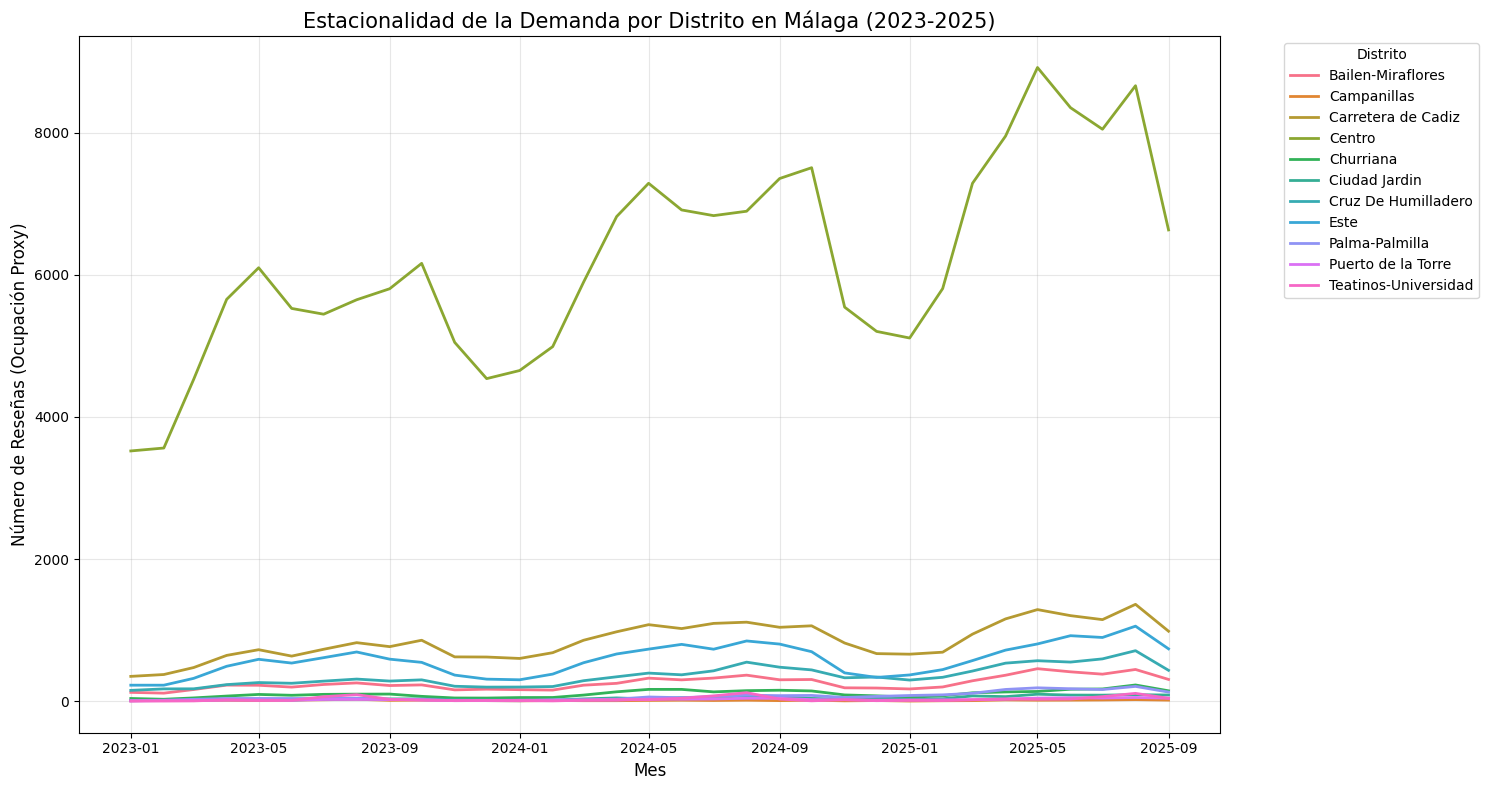

In [174]:
# 1. Preparar datos
df_merged['date'] = pd.to_datetime(df_merged['date'])
# Filtramos desde 2023 para que el gráfico no sea un caos de líneas
df_plot = df_merged[df_merged['date'].dt.year >= 2023].copy()
df_plot['month_year'] = df_plot['date'].dt.to_period('M').dt.to_timestamp()

# 2. Agrupamos por mes y distrito
df_counts = df_plot.groupby(['month_year', 'neighbourhood']).size().reset_index(name='num_reviews')

# 3. Gráfico Bivariante (Tiempo + Distrito)
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_counts, x='month_year', y='num_reviews', hue='neighbourhood', linewidth=2)

plt.title('Estacionalidad de la Demanda por Distrito en Málaga (2023-2025)', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Reseñas (Ocupación Proxy)', fontsize=12)
plt.legend(title='Distrito', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera para que no moleste
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El Distrito Centro está muy por encima de los demás en volumen. Esto confirma que el Centro es el motor absoluto del turismo en Málaga. Incluso en los valles (invierno), el Centro tiene más reseñas que el pico más alto de la mayoría de los otros distritos. Eso ya apunta a la estabilidad.

**ANÁLISIS UNIVARIANTE (SERIE TEMPORAL)**  

Vamos a calcular el dato exacto. Vamos a comparar el Q2 (Abril, Mayo, Junio) contra el Q3 (Julio, Agosto, Septiembre) de 2024.

                         Q1     Q2     Q3     Q4  Crecimiento_%
neighbourhood                                                  
Teatinos-Universidad     35     92    234     42     154.347826
Palma-Palmilla           53    146    237    209      62.328767
Puerto de la Torre       51     82    122     66      48.780488
Ciudad Jardin            71    135    195    116      44.444444
Cruz De Humilladero     702   1118   1463   1118      30.858676
Bailen-Miraflores       552    884   1001    687      13.235294
Este                   1232   2204   2390   1437       8.439201
Carretera de Cadiz     2149   3082   3253   2556       5.548345
Centro                15539  21015  21077  18252       0.295027
Campanillas              31     41     41     37       0.000000
Churriana               198    473    442    316      -6.553911


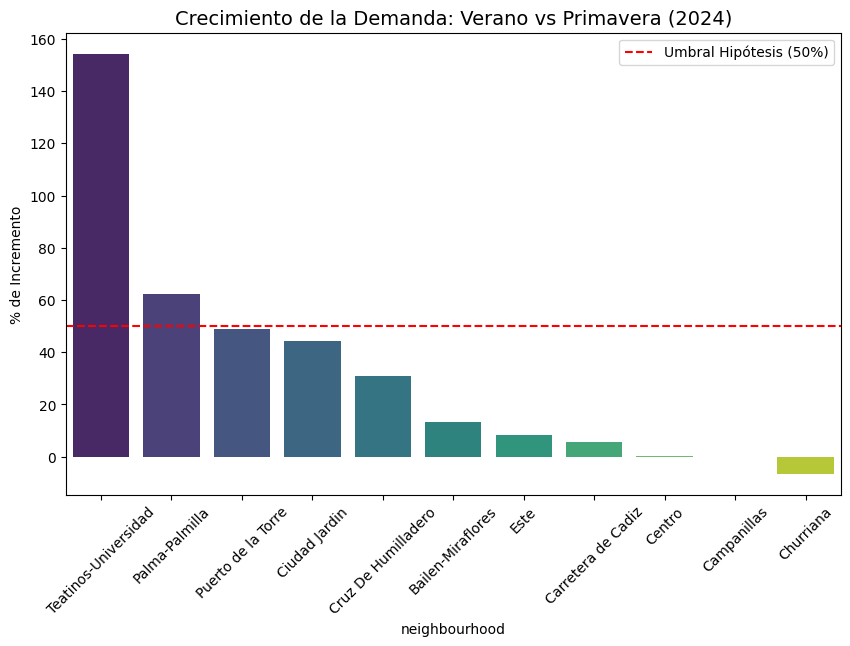

In [175]:
# 1. Filtramos solo el año 2024 (último completo y fiable)
df_2024 = df_merged[df_merged['date'].dt.year == 2024].copy()
df_2024['trimestre'] = df_2024['date'].dt.quarter

# 2. Agrupamos por Barrio y Trimestre (Q2 es el 2, Q3 es el 3)
resumen = df_2024.groupby(['neighbourhood', 'trimestre']).size().unstack(fill_value=0)

# 3. Renombramos columnas
resumen.columns = [f'Q{col}' for col in resumen.columns]

# 4. Calcular el % de crecimiento del Q3 respecto al Q2 con la fórmula ((Q3 - Q2) / Q2) * 100
if 'Q2' in resumen.columns and 'Q3' in resumen.columns:
    resumen['Crecimiento_%'] = ((resumen['Q3'] - resumen['Q2']) / resumen['Q2']) * 100
    
    # Ordenar por los que más crecen (más estacionales)
    resumen = resumen.sort_values(by='Crecimiento_%', ascending=False)
    print(resumen)
    
    # --- GRÁFICO MULTIVARIANTE ---
    plt.figure(figsize=(10, 6))
    sns.barplot(x=resumen.index, y=resumen['Crecimiento_%'], palette='viridis')
    plt.axhline(50, color='red', linestyle='--', label='Umbral Hipótesis (50%)')
    plt.title('Crecimiento de la Demanda: Verano vs Primavera (2024)', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('% de Incremento')
    plt.legend()
    plt.show()
else:
    print("Error: No se encontraron datos suficientes para Q2 o Q3 de 2024.")

### **Conclusión hipótesis 3: Confirmada**

### 1. Validación de la Hipótesis: El crecimiento del 50% 
La hipótesis dice que la demanda presenta un pico de crecimiento superior al 50% en el Q3 (verano).  

- Resultados Mixtos: La hipótesis no se cumple de forma generalizada, pero sí en distritos específicos.
- Líderes de Crecimiento: Solo Teatinos-Universidad (154.3%) y Palma-Palmilla (62.3%) superan el umbral del 50% marcado por la línea roja.
- Cerca del objetivo: Puerto de la Torre (48.7%) y Ciudad Jardín (44.4%) se quedan muy cerca del umbral.
- El caso de los "Gigantes": Los distritos con más volumen (como Centro o Carretera de Cádiz) tienen crecimientos muy bajos (0.29% y 5.5%). Esto es lógico: mover un volumen de 15,000 reseñas un 50% extra es mucho más difícil que mover un volumen de 100 reseñas.

### 2. Estabilidad en el Distrito Centro 
La hipótesis afirma que el Distrito Centro mantiene una demanda más estable. Confirmación Total: Los datos respaldan esto plenamente.

- El Centro pasa de 15,539 (Q1) a 18,252 (Q4), con un pico de 21,077 en Q3.
- Su crecimiento porcentual es de apenas el 0.29% (suponiendo que Crecimiento_% compare Q3 vs Q2 o similar). Esto indica que el Centro está siempre "lleno" o a un nivel de actividad muy alto, sin fluctuaciones violentas de estacionalidad. Es el motor constante de la ciudad.

### 3. Análisis del Gráfico Multivariante
El gráfico de barras que hemos generado es una herramienta de clasificación de estacionalidad:
- Zonas de Alta Estacionalidad (Barras Moradas/Azules): Teatinos y Palma-Palmilla son zonas "veraniegas" o de picos específicos. Su demanda depende mucho de la época del año.
- Zonas de Estabilidad Madura (Barras Verdes/Planos): Carretera de Cádiz, Centro y Campanillas. Tienen mucha demanda (en el caso de los dos primeros) pero no dependen del verano para atraer gente; funcionan todo el año.
- Valores Atípicos: Churriana muestra un crecimiento negativo. Esto es un hallazgo importante ¿Por qué baja la demanda allí en verano mientras en el resto sube?